In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = sns.load_dataset('iris')

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  149 non-null    float64
 1   sepal_width   149 non-null    float64
 2   petal_length  149 non-null    float64
 3   petal_width   149 non-null    float64
 4   species       149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [ ]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Count'>

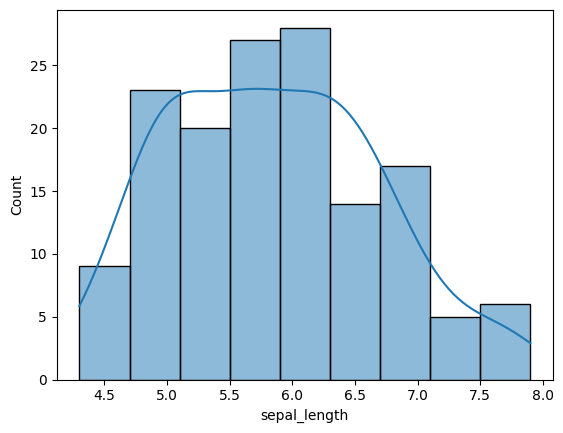

In [ ]:
sns.histplot(data=df,x='sepal_length', kde=True)

<Axes: xlabel='species', ylabel='sepal_length'>

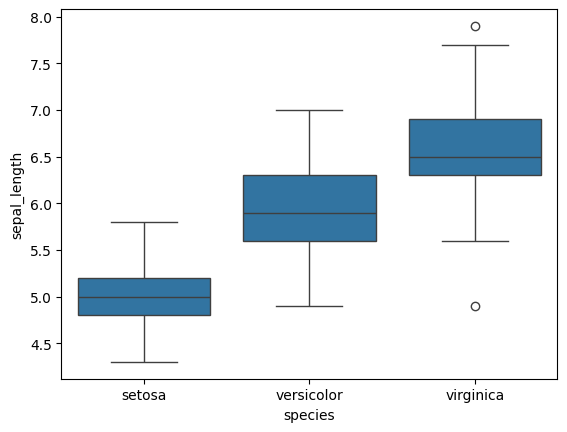

In [ ]:
sns.boxplot(data=df ,x='species', y='sepal_length')

<Axes: xlabel='species', ylabel='sepal_length'>

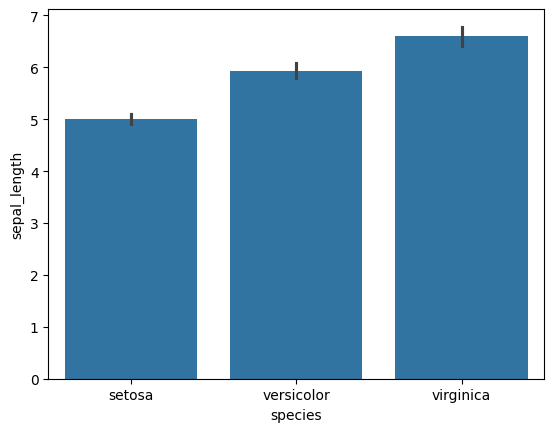

In [ ]:
sns.barplot(data=df ,x='species', y='sepal_length')

<Axes: xlabel='sepal_width', ylabel='Count'>

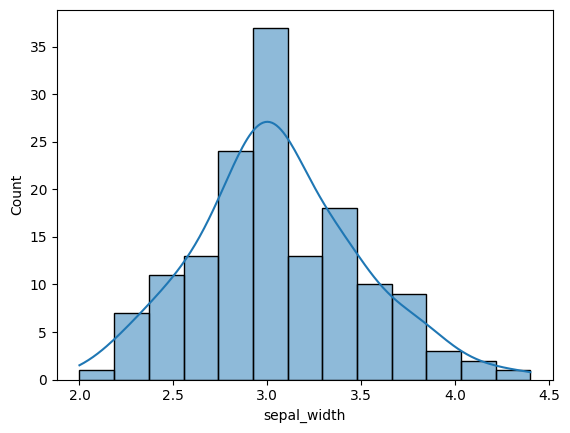

In [ ]:
sns.histplot(data=df , x='sepal_width', kde = True)

<Axes: xlabel='species', ylabel='sepal_width'>

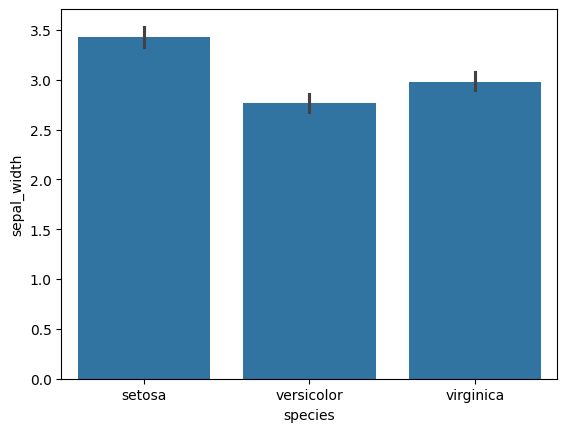

In [ ]:
sns.barplot(data=df ,x='species', y='sepal_width')

<Axes: xlabel='species', ylabel='sepal_width'>

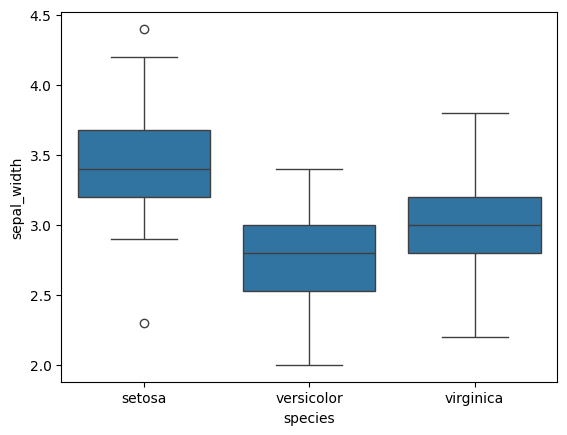

In [ ]:
sns.boxplot(data=df ,x='species', y='sepal_width')

In [ ]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

<Axes: xlabel='petal_length', ylabel='Count'>

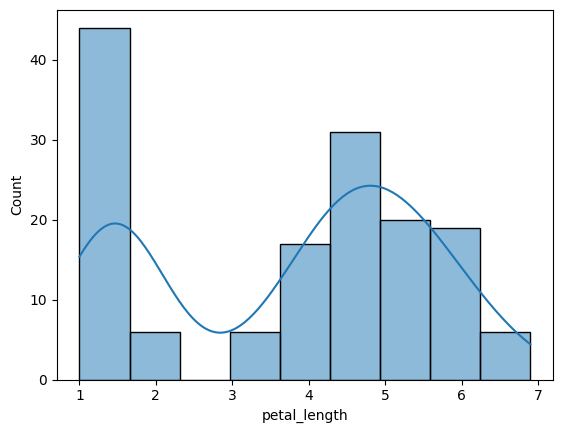

In [ ]:
sns.histplot(data=df , x='petal_length', kde=True)

<Axes: xlabel='species', ylabel='petal_length'>

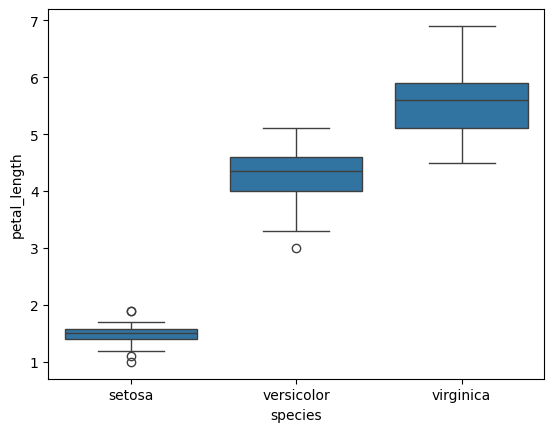

In [ ]:
sns.boxplot(data=df , x='species' , y='petal_length')
# As we can see setosa petal length is between 1-2 , That's why in histplot we can see a space

<Axes: xlabel='petal_width', ylabel='Count'>

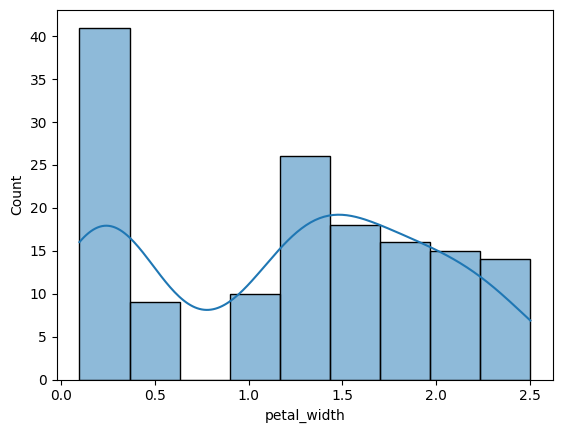

In [ ]:
sns.histplot(data=df, x='petal_width', kde=True)

<Axes: xlabel='species', ylabel='petal_width'>

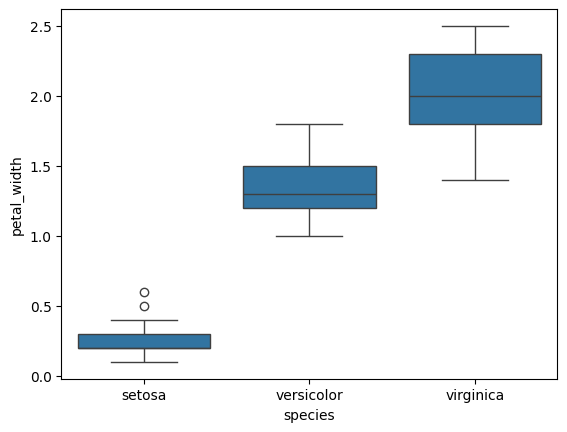

In [ ]:
sns.boxplot(data=df,x='species' , y='petal_width')

In [ ]:
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,49


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
df['species'] = le.fit_transform(df['species'])

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df['species'].value_counts()

,count
species,
0,50
1,50
2,49


In [ ]:
x= df.drop(columns=['species'])
y = df['species']

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2, random_state = 42)
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()
model.fit(x_train , y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score , confusion_matrix ,f1_score, precision_score , recall_score

In [24]:
print('Accuracy:', accuracy_score(y_test,y_pred))
print('Precision:', precision_score(y_test,y_pred, average = 'macro'))
print('Recall:', recall_score(y_test,y_pred, average='macro'))
print('Confusion_matrix:', confusion_matrix(y_test,y_pred))
print('F1_score:', f1_score(y_test,y_pred, average='macro'))

# In this model we have small size of data , so that we got an perfect score or it can be data leake ;)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Confusion_matrix: [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
F1_score: 1.0
